# EDA

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
master = pd.read_csv("data/master.csv")

# ── 1. Basic distributions ───────────────────────────────────
print("=== KEY VARIABLE DISTRIBUTIONS ===")
cols = ["rec_points", "draft_score_total", "development_residual", 
        "sp_rating", "win_pct"]
print(master[cols].describe().round(2))

# ── 2. How skewed is draft production? ──────────────────────
print("\n=== DRAFT SCORE DISTRIBUTION ===")
print(f"Programs with 0 draft score: {(master['draft_score_total'] == 0).sum()}")
print(f"Programs with score > 100:   {(master['draft_score_total'] > 100).sum()}")
print(f"Programs with score > 200:   {(master['draft_score_total'] > 200).sum()}")
print(f"Median draft score: {master['draft_score_total'].median():.1f}")
print(f"Mean draft score:   {master['draft_score_total'].mean():.1f}")

# ── 3. Top and bottom developers ────────────────────────────
print("\n=== TOP 15 DEVELOPERS (highest avg residual) ===")
top_dev = (master.groupby("team")["development_residual"]
           .agg(["mean", "count"])
           .query("count >= 5")
           .sort_values("mean", ascending=False)
           .head(15)
           .round(2))
print(top_dev)

print("\n=== BOTTOM 15 DEVELOPERS (lowest avg residual) ===")
bot_dev = (master.groupby("team")["development_residual"]
           .agg(["mean", "count"])
           .query("count >= 5")
           .sort_values("mean")
           .head(15)
           .round(2))
print(bot_dev)

# ── 4. Recruiting vs wins relationship ──────────────────────
print("\n=== CORRELATIONS WITH WIN PCT ===")
corr_cols = ["rec_points", "draft_score_total", "development_residual", 
             "sp_rating", "rec_rank"]
for col in corr_cols:
    corr = master[["win_pct", col]].dropna().corr().iloc[0, 1]
    print(f"  win_pct vs {col}: {corr:.3f}")

# ── 5. Does development residual predict wins? ───────────────
print("\n=== CORRELATIONS WITH SP RATING ===")
for col in ["rec_points", "draft_score_total", "development_residual"]:
    corr = master[["sp_rating", col]].dropna().corr().iloc[0, 1]
    print(f"  sp_rating vs {col}: {corr:.3f}")

# ── 6. Most interesting individual observations ──────────────
print("\n=== TOP 10 SINGLE SEASON OVERPERFORMERS ===")
print(master.nlargest(10, "development_residual")
      [["year", "team", "rec_points", "rec_rank", 
        "draft_score_total", "development_residual"]].to_string())

print("\n=== TOP 10 SINGLE SEASON UNDERPERFORMERS ===")
print(master.nsmallest(10, "development_residual")
      [["year", "team", "rec_points", "rec_rank",
        "draft_score_total", "development_residual"]].to_string())

# ── 7. Conference level patterns ────────────────────────────
print("\n=== AVERAGE DEVELOPMENT RESIDUAL BY CONFERENCE ===")
conf_dev = (master.groupby("conference")["development_residual"]
            .agg(["mean", "count"])
            .query("count >= 20")
            .sort_values("mean", ascending=False)
            .round(2))
print(conf_dev)

=== KEY VARIABLE DISTRIBUTIONS ===
       rec_points  draft_score_total  development_residual  sp_rating  win_pct
count     1868.00            1868.00               1868.00    1495.00  1496.00
mean       135.23              14.95                  0.00       1.66     0.52
std         78.83              19.85                 13.92      14.59     0.22
min         -0.11               0.00                -29.85     -38.90     0.00
25%         77.39               1.00                 -9.42      -9.40     0.33
50%        137.21               7.00                 -1.80       2.30     0.54
75%        192.10              21.00                  7.01      12.20     0.69
max        324.62             145.00                100.34      38.50     1.00

=== DRAFT SCORE DISTRIBUTION ===
Programs with 0 draft score: 374
Programs with score > 100:   18
Programs with score > 200:   0
Median draft score: 7.0
Mean draft score:   15.0

=== TOP 15 DEVELOPERS (highest avg residual) ===
                     mean

First Notes:

- Finding 1: Recruiting explains only 39% of wins. Development residual adds an independent 26.9% of variation of wins.
- Finding 2: SEC development gap. The SEC has an average residual of +7.95 while every Group of 5 conference is negative
- Finding 3: Alabama's average residual is +65 and Ohio State's average residual is +43. Very large outliers
- Finding 5: The draft score data is extremely right skewed because 374 programs had 0 draft score in a given year

In [4]:

master = pd.read_csv("data/master.csv")

# ── 1. Is the recruiting → draft relationship linear or curved? ──
# Bin recruiting points into deciles and see average draft score per bin
master["rec_decile"] = pd.qcut(master["rec_points"], q=10, labels=False)
print("=== DRAFT SCORE BY RECRUITING DECILE ===")
print(master.groupby("rec_decile")[["rec_points", "draft_score_total"]]
      .mean().round(2).to_string())

# ── 2. How does development residual distribute? ─────────────
print("\n=== DEVELOPMENT RESIDUAL PERCENTILES ===")
percentiles = [5, 10, 25, 50, 75, 90, 95]
for p in percentiles:
    val = np.percentile(master["development_residual"], p)
    print(f"  {p}th percentile: {val:.2f}")

# ── 3. Tennessee deep dive ───────────────────────────────────
print("\n=== TENNESSEE YEAR BY YEAR ===")
print(master[master["team"] == "Tennessee"]
      [["year", "rec_rank", "rec_points", "draft_score_total", 
        "development_residual", "win_pct", "coach_name"]]
      .to_string())

# ── 4. Check Alabama/OSU are true outliers ───────────────────
print("\n=== RESIDUAL DISTRIBUTION FOR TOP PROGRAMS ===")
top_programs = ["Alabama", "Ohio State", "LSU", "Florida", 
                "Clemson", "USC", "Georgia"]
print(master[master["team"].isin(top_programs)]
      .groupby("team")["development_residual"]
      .describe().round(2).to_string())

=== DRAFT SCORE BY RECRUITING DECILE ===
            rec_points  draft_score_total
rec_decile                               
0                 9.15               1.44
1                33.40               1.86
2                76.04               4.27
3               105.26               5.06
4               125.95               7.25
5               148.76              11.09
6               169.84              14.48
7               192.66              21.98
8               219.84              28.20
9               271.38              53.83

=== DEVELOPMENT RESIDUAL PERCENTILES ===
  5th percentile: -17.51
  10th percentile: -14.52
  25th percentile: -9.42
  50th percentile: -1.80
  75th percentile: 7.01
  90th percentile: 13.59
  95th percentile: 22.63

=== TENNESSEE YEAR BY YEAR ===
      year  rec_rank  rec_points  draft_score_total  development_residual   win_pct      coach_name
3     2005         4      276.14                 46              5.950039  0.454545  Phillip Fulmer
146   

The recruiting to draft relationship is exponential. The jump from residual 8 (average of 28) to decile 9 (average is 54) is very large. 

The residual distribution is right skewed. Median of -1.8 means most programs slightly underperform. 

### Correlation Matrix

                      rec_points  draft_score_total  development_residual  \
rec_points                 1.000              0.713                 0.008   
draft_score_total          0.713              1.000                 0.707   
development_residual       0.008              0.707                 1.000   
sp_rating                  0.716              0.625                 0.338   
win_pct                    0.399              0.406                 0.269   
first_round_total          0.556              0.879                 0.692   

                      sp_rating  win_pct  first_round_total  
rec_points                0.716    0.399              0.556  
draft_score_total         0.625    0.406              0.879  
development_residual      0.338    0.269              0.692  
sp_rating                 1.000    0.800              0.490  
win_pct                   0.800    1.000              0.330  
first_round_total         0.490    0.330              1.000  


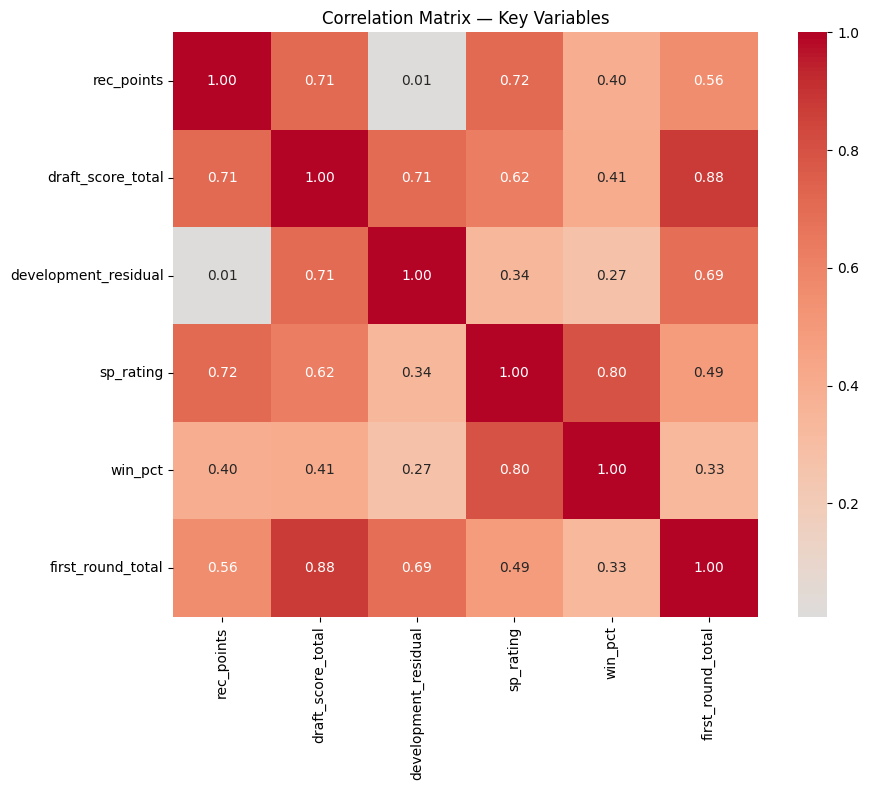

In [10]:
corr_cols = ["rec_points", "draft_score_total", "development_residual",
             "sp_rating", "win_pct", "first_round_total"]

corr_matrix = complete[corr_cols].corr().round(3)
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True)
plt.title("Correlation Matrix — Key Variables")
plt.tight_layout()
plt.savefig
plt.show()

- development_residual vs rec_points = .01. Being near zero confirms that the residual is independent of recruiting
- rec_points vs win_pct = .40

### Quick Time Series Plots

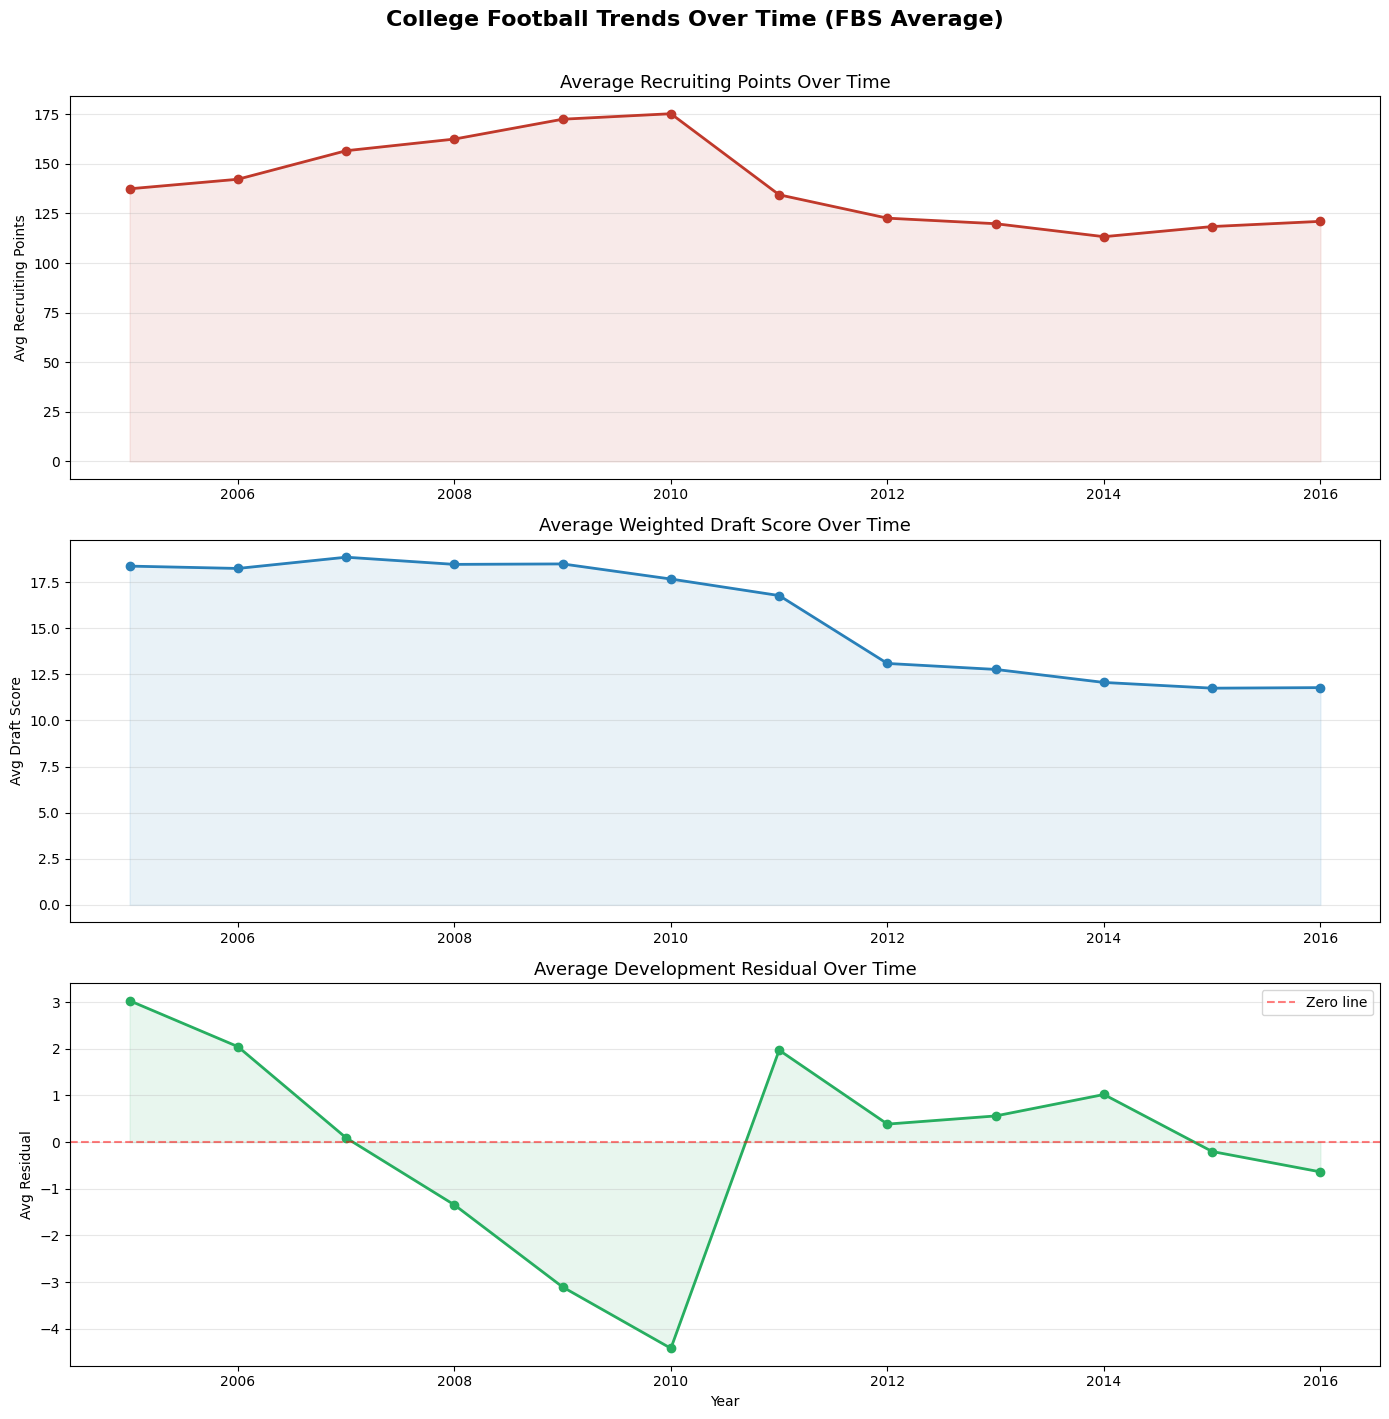

In [12]:

yearly = (complete.groupby("year")
          .agg(
              avg_rec_points=("rec_points", "mean"),
              avg_draft_score=("draft_score_total", "mean"),
              avg_dev_residual=("development_residual", "mean"),
              avg_win_pct=("win_pct", "mean"),
              avg_sp_rating=("sp_rating", "mean")
          ).reset_index())

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("College Football Trends Over Time (FBS Average)", 
             fontsize=16, fontweight="bold", y=1.01)

axes[0].plot(yearly["year"], yearly["avg_rec_points"], 
             marker="o", linewidth=2, color="#c0392b", markersize=6)
axes[0].fill_between(yearly["year"], yearly["avg_rec_points"], 
                     alpha=0.1, color="#c0392b")
axes[0].set_title("Average Recruiting Points Over Time", fontsize=13)
axes[0].set_ylabel("Avg Recruiting Points")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(yearly["year"], yearly["avg_draft_score"],
             marker="o", linewidth=2, color="#2980b9", markersize=6)
axes[1].fill_between(yearly["year"], yearly["avg_draft_score"],
                     alpha=0.1, color="#2980b9")
axes[1].set_title("Average Weighted Draft Score Over Time", fontsize=13)
axes[1].set_ylabel("Avg Draft Score")
axes[1].grid(axis="y", alpha=0.3)

axes[2].plot(yearly["year"], yearly["avg_dev_residual"],
             marker="o", linewidth=2, color="#27ae60", markersize=6)
axes[2].fill_between(yearly["year"], yearly["avg_dev_residual"],
                     alpha=0.1, color="#27ae60")
axes[2].axhline(y=0, color="red", linestyle="--", alpha=0.5, label="Zero line")
axes[2].set_title("Average Development Residual Over Time", fontsize=13)
axes[2].set_ylabel("Avg Residual")
axes[2].set_xlabel("Year")
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

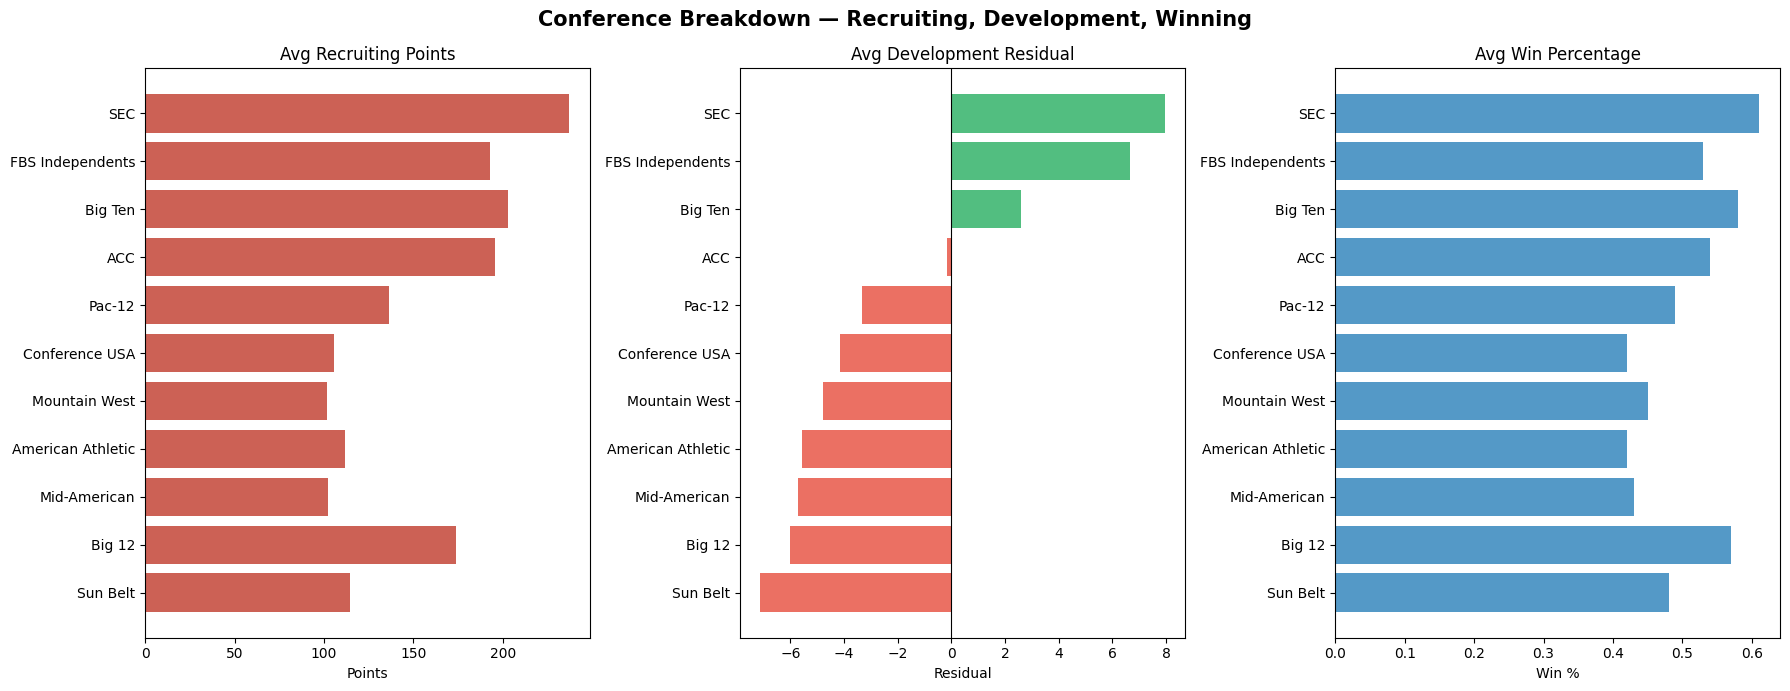

In [13]:
conf_analysis = (complete.groupby("conference")
                 .agg(
                     avg_rec_points=("rec_points", "mean"),
                     avg_draft_score=("draft_score_total", "mean"),
                     avg_dev_residual=("development_residual", "mean"),
                     avg_win_pct=("win_pct", "mean"),
                     n=("year", "count")
                 )
                 .query("n >= 20")
                 .sort_values("avg_dev_residual", ascending=False)
                 .round(2)
                 .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Conference Breakdown — Recruiting, Development, Winning",
             fontsize=15, fontweight="bold")

# Avg recruiting points by conference
axes[0].barh(conf_analysis["conference"], conf_analysis["avg_rec_points"],
             color="#c0392b", alpha=0.8)
axes[0].set_title("Avg Recruiting Points")
axes[0].set_xlabel("Points")
axes[0].invert_yaxis()

# Avg development residual by conference
colors = ["#27ae60" if x > 0 else "#e74c3c" 
          for x in conf_analysis["avg_dev_residual"]]
axes[1].barh(conf_analysis["conference"], conf_analysis["avg_dev_residual"],
             color=colors, alpha=0.8)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_title("Avg Development Residual")
axes[1].set_xlabel("Residual")
axes[1].invert_yaxis()

# Avg win pct by conference
axes[2].barh(conf_analysis["conference"], conf_analysis["avg_win_pct"],
             color="#2980b9", alpha=0.8)
axes[2].set_title("Avg Win Percentage")
axes[2].set_xlabel("Win %")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

- SEC: They are recruiting better than any conference, and develop their players at the best rate
- Big 12: they recruit well (4th in recruiting points), but have the second worst development residual, but they still have a high win %

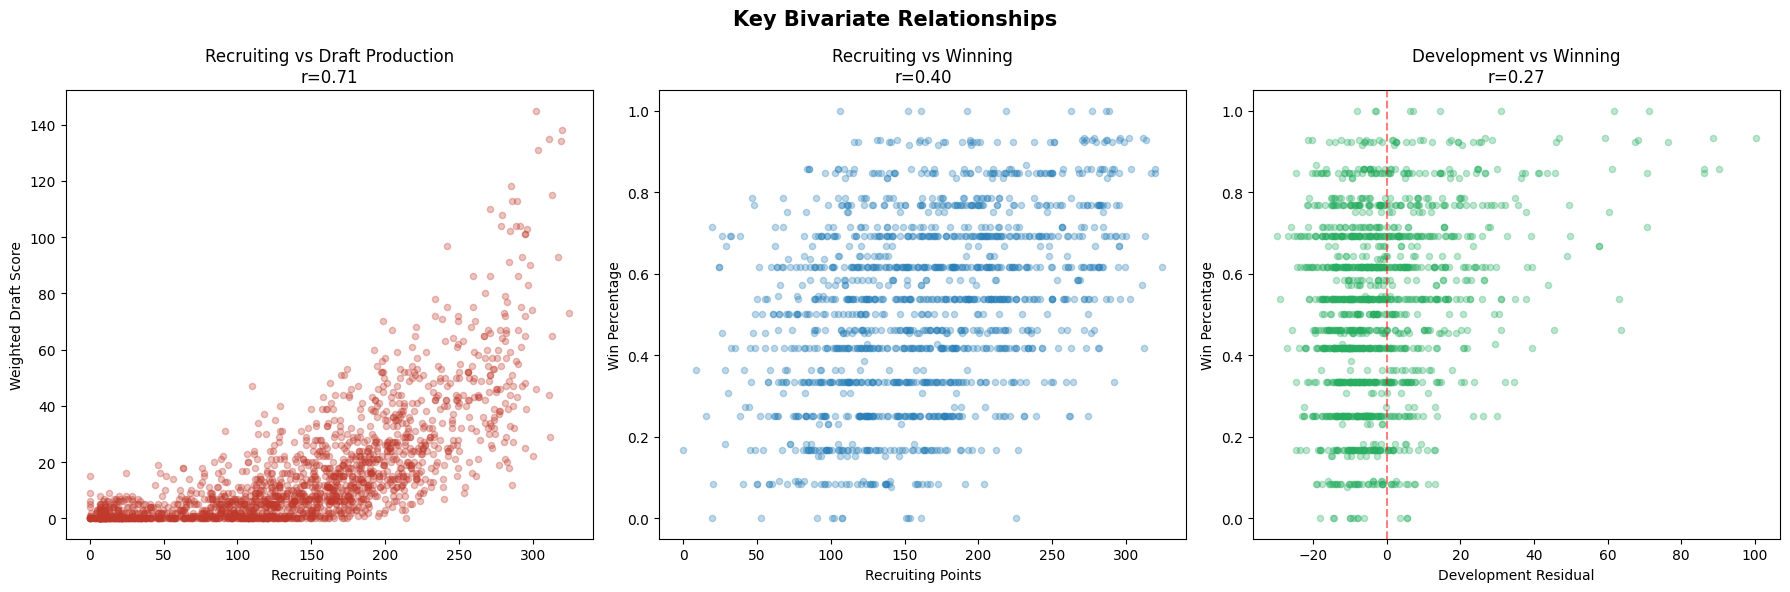

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Key Bivariate Relationships", fontsize=15, fontweight="bold")

# Recruiting vs Draft Score
axes[0].scatter(complete["rec_points"], complete["draft_score_total"],
                alpha=0.3, s=20, color="#c0392b")
axes[0].set_xlabel("Recruiting Points")
axes[0].set_ylabel("Weighted Draft Score")
axes[0].set_title("Recruiting vs Draft Production\nr=0.71")

# Recruiting vs Win Pct
axes[1].scatter(complete["rec_points"], complete["win_pct"],
                alpha=0.3, s=20, color="#2980b9")
axes[1].set_xlabel("Recruiting Points")
axes[1].set_ylabel("Win Percentage")
axes[1].set_title("Recruiting vs Winning\nr=0.40")

# Development Residual vs Win Pct
axes[2].scatter(complete["development_residual"], complete["win_pct"],
                alpha=0.3, s=20, color="#27ae60")
axes[2].axvline(x=0, color="red", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Development Residual")
axes[2].set_ylabel("Win Percentage")
axes[2].set_title("Development vs Winning\nr=0.27")

plt.tight_layout()
plt.show()

- Clear positive relationship between recruiting and draft production. 
- Recruiting vs winning is weak and noisy. Lots of low recruiting programs winning 60-70% of games, and high recruiting programs losing frequently.
- Development vs winning: The programs with very negative residuals are spread across al win percentages. You can win without developing NFL talent/

### Outlier Identification

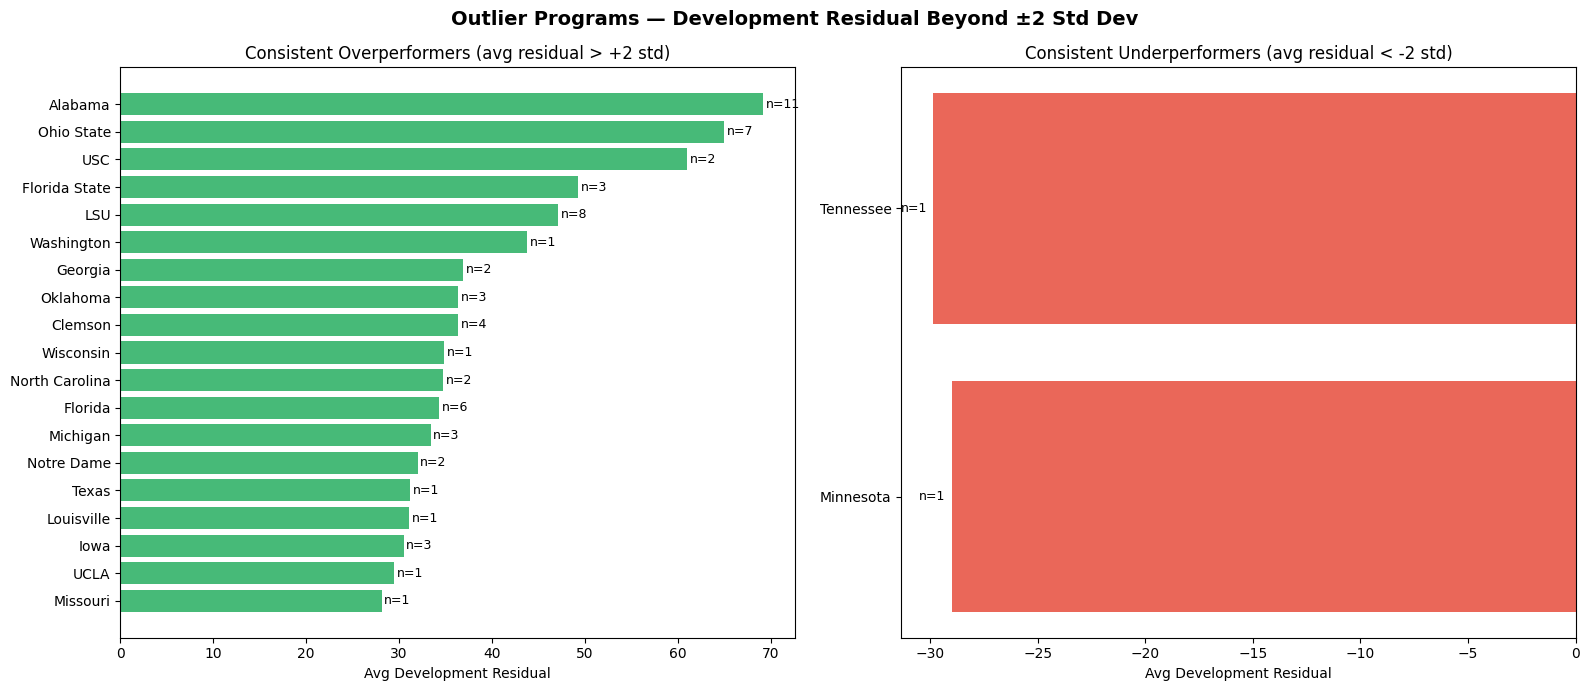

In [15]:
mean_res = complete["development_residual"].mean()
std_res = complete["development_residual"].std()
threshold = 2 * std_res

outliers_high = (complete[complete["development_residual"] > mean_res + threshold]
                 .groupby("team")["development_residual"]
                 .agg(["mean", "count"])
                 .sort_values("mean", ascending=False)
                 .reset_index())

outliers_low = (complete[complete["development_residual"] < mean_res - threshold]
                .groupby("team")["development_residual"]
                .agg(["mean", "count"])
                .sort_values("mean")
                .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Outlier Programs — Development Residual Beyond ±2 Std Dev",
             fontsize=14, fontweight="bold")

# Top overperformers
axes[0].barh(outliers_high["team"], outliers_high["mean"],
             color="#27ae60", alpha=0.85)
axes[0].set_title("Consistent Overperformers (avg residual > +2 std)")
axes[0].set_xlabel("Avg Development Residual")
axes[0].invert_yaxis()
for i, (val, cnt) in enumerate(zip(outliers_high["mean"], outliers_high["count"])):
    axes[0].text(val + 0.3, i, f"n={cnt}", va="center", fontsize=9)

# Top underperformers
axes[1].barh(outliers_low["team"], outliers_low["mean"],
             color="#e74c3c", alpha=0.85)
axes[1].set_title("Consistent Underperformers (avg residual < -2 std)")
axes[1].set_xlabel("Avg Development Residual")
axes[1].invert_yaxis()
for i, (val, cnt) in enumerate(zip(outliers_low["mean"], outliers_low["count"])):
    axes[1].text(val - 0.3, i, f"n={cnt}", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

### VIF

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = complete[["rec_points", "sp_rating", 
                      "win_pct", "draft_score_total",
                      "development_residual"]].dropna()

vif_results = pd.DataFrame()
vif_results["feature"] = vif_data.columns
vif_results["VIF"] = [
    variance_inflation_factor(vif_data.values, i) 
    for i in range(vif_data.shape[1])
]
print(vif_results.round(2).to_string())

                feature     VIF
0            rec_points  399.97
1             sp_rating    5.94
2               win_pct    3.38
3     draft_score_total  442.07
4  development_residual  133.00


Going to try to drop draft score total and sp rating to see if that lowers VIF of the remaining features. These two features are already captured by the others

In [17]:
vif_data = complete[["rec_points", "development_residual", "win_pct"]].dropna()

vif_results = pd.DataFrame()
vif_results["feature"] = vif_data.columns
vif_results["VIF"] = [
    variance_inflation_factor(vif_data.values, i) 
    for i in range(vif_data.shape[1])
]
print(vif_results.round(2).to_string())

                feature   VIF
0            rec_points  6.12
1  development_residual  1.00
2               win_pct  6.12


### Trying to see what typically comes first among: wins, recruits, or draft results

In [21]:

# For each program compute lag correlations
# rec_points(T) vs win_pct(T+1), T+2, T+3
# win_pct(T) vs rec_points(T+1), T+2, T+3

results = []

for team, group in complete.groupby("team"):
    group = group.sort_values("year").reset_index(drop=True)
    
    # Need at least 7 seasons for meaningful lag correlations
    if len(group) < 7:
        continue
    
    for lag in [1, 2, 3]:
        # Does recruiting predict future winning?
        rec_leads_win = group["rec_points"].corr(
            group["win_pct"].shift(-lag)
        )
        
        # Does winning predict future recruiting?
        win_leads_rec = group["win_pct"].corr(
            group["rec_points"].shift(-lag)
        )
        
        results.append({
            "team": team,
            "lag": lag,
            "rec_leads_win": rec_leads_win,
            "win_leads_rec": win_leads_rec
        })

lag_df = pd.DataFrame(results)

# Average across all programs by lag
print("=== AVERAGE LAG CORRELATIONS ACROSS ALL FBS PROGRAMS ===")
avg_lags = lag_df.groupby("lag")[["rec_leads_win", "win_leads_rec"]].mean().round(3)
print(avg_lags)
print()

# Find programs where recruiting clearly leads winning
print("=== TOP 10 PROGRAMS WHERE RECRUITING LEADS WINNING (lag=2) ===")
rec_first = (lag_df[lag_df["lag"] == 2]
             .nlargest(10, "rec_leads_win")
             [["team", "rec_leads_win", "win_leads_rec"]]
             .round(3))
print(rec_first.to_string())

print()

# Find programs where winning clearly leads recruiting
print("=== TOP 10 PROGRAMS WHERE WINNING LEADS RECRUITING (lag=2) ===")
win_first = (lag_df[lag_df["lag"] == 2]
             .nlargest(10, "win_leads_rec")
             [["team", "win_leads_rec", "rec_leads_win"]]
             .round(3))
print(win_first.to_string())

=== AVERAGE LAG CORRELATIONS ACROSS ALL FBS PROGRAMS ===
     rec_leads_win  win_leads_rec
lag                              
1            0.045          0.128
2            0.042          0.128
3           -0.007          0.063

=== TOP 10 PROGRAMS WHERE RECRUITING LEADS WINNING (lag=2) ===
                      team  rec_leads_win  win_leads_rec
94           Georgia State          0.888          0.639
178               NC State          0.775         -0.475
34                  Baylor          0.723          0.391
142             Louisville          0.676         -0.398
82   Florida International          0.650         -0.182
328             Utah State          0.619          0.512
85           Florida State          0.617          0.461
289                 Toledo          0.599         -0.401
139         Louisiana Tech          0.589          0.233
181                   Navy          0.569         -0.216

=== TOP 10 PROGRAMS WHERE WINNING LEADS RECRUITING (lag=2) ===
                  

/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [22]:
results = []

for team, group in complete.groupby("team"):
    group = group.sort_values("year").reset_index(drop=True)
    
    if len(group) < 7:
        continue
    
    for lag in [1, 2, 3]:
        # Recruiting → Winning
        rec_leads_win = group["rec_points"].corr(
            group["win_pct"].shift(-lag))
        
        # Winning → Recruiting
        win_leads_rec = group["win_pct"].corr(
            group["rec_points"].shift(-lag))
        
        # Recruiting → Draft
        rec_leads_draft = group["rec_points"].corr(
            group["draft_score_total"].shift(-lag))
        
        # Draft → Recruiting
        draft_leads_rec = group["draft_score_total"].corr(
            group["rec_points"].shift(-lag))
        
        # Winning → Draft
        win_leads_draft = group["win_pct"].corr(
            group["draft_score_total"].shift(-lag))
        
        # Draft → Winning
        draft_leads_win = group["draft_score_total"].corr(
            group["win_pct"].shift(-lag))
        
        results.append({
            "team": team,
            "lag": lag,
            "rec_leads_win": rec_leads_win,
            "win_leads_rec": win_leads_rec,
            "rec_leads_draft": rec_leads_draft,
            "draft_leads_rec": draft_leads_rec,
            "win_leads_draft": win_leads_draft,
            "draft_leads_win": draft_leads_win
        })

lag_df = pd.DataFrame(results)

print("=== AVERAGE LAG CORRELATIONS ACROSS ALL FBS PROGRAMS ===")
avg_lags = (lag_df.groupby("lag")
            [["rec_leads_win", "win_leads_rec",
              "rec_leads_draft", "draft_leads_rec",
              "win_leads_draft", "draft_leads_win"]]
            .mean().round(3))
print(avg_lags.to_string())

=== AVERAGE LAG CORRELATIONS ACROSS ALL FBS PROGRAMS ===
     rec_leads_win  win_leads_rec  rec_leads_draft  draft_leads_rec  win_leads_draft  draft_leads_win
lag                                                                                                  
1            0.045          0.128            0.013            0.086           -0.073            0.133
2            0.042          0.128           -0.043            0.028           -0.085            0.332
3           -0.007          0.063           -0.039            0.013           -0.050            0.335


/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


- Clearest pattern: draft production leads to future winning (.332 at lag 2 and .335 at lag 3). Programs that produce NFL talent see their winning improve 2-3 years later.
- Winning leads future recruitment (0.128 at lag 1 and 2). Winning leads to getting better recruits
- Recruiting does not lead winning or draft production. rec_leads_wins and rec_leads draft are near zero or negative across all lags.

Building the narrative: Develop players into NFL talent, and the wins follow 2-3 years later. Recruiting is largerly a lagging indicator, not a leading one

In [25]:
results = []

for team, group in complete.groupby("team"):
    group = group.sort_values("year").reset_index(drop=True)
    
    if len(group) < 7:
        continue
    
    for lag in [1, 2, 3]:
        rec_leads_win = group["rec_points"].corr(group["win_pct"].shift(-lag))
        win_leads_rec = group["win_pct"].corr(group["rec_points"].shift(-lag))
        rec_leads_draft = group["rec_points"].corr(group["draft_score_total"].shift(-lag))
        draft_leads_rec = group["draft_score_total"].corr(group["rec_points"].shift(-lag))
        win_leads_draft = group["win_pct"].corr(group["draft_score_total"].shift(-lag))
        draft_leads_win = group["draft_score_total"].corr(group["win_pct"].shift(-lag))
        dev_leads_win = group["development_residual"].corr(group["win_pct"].shift(-lag))

        results.append({
            "team": team,
            "lag": lag,
            "rec_leads_win": rec_leads_win,
            "win_leads_rec": win_leads_rec,
            "rec_leads_draft": rec_leads_draft,
            "draft_leads_rec": draft_leads_rec,
            "win_leads_draft": win_leads_draft,
            "draft_leads_win": draft_leads_win,
            "dev_leads_win": dev_leads_win
        })

lag_df = pd.DataFrame(results)

print("=== AVERAGE LAG CORRELATIONS ACROSS ALL FBS PROGRAMS ===")
avg_lags = (lag_df.groupby("lag")
            [["rec_leads_win", "win_leads_rec",
              "rec_leads_draft", "draft_leads_rec",
              "win_leads_draft", "draft_leads_win",
              "dev_leads_win"]]
            .mean().round(3))
print(avg_lags.to_string())

=== AVERAGE LAG CORRELATIONS ACROSS ALL FBS PROGRAMS ===
     rec_leads_win  win_leads_rec  rec_leads_draft  draft_leads_rec  win_leads_draft  draft_leads_win  dev_leads_win
lag                                                                                                                 
1            0.045          0.128            0.013            0.086           -0.073            0.133          0.100
2            0.042          0.128           -0.043            0.028           -0.085            0.332          0.265
3           -0.007          0.063           -0.039            0.013           -0.050            0.335          0.280


/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Hierarchy of what predicts future winning:

- draft leads wins at lag 2-3: 0.332-0.335
- dev leads win at lag 2-3: 0.265-0.280
- win leads recruits: at lag 1-2: 0.128
- rec leads wins: at all lags roughly .04 (nearly 0)

#### Looking at programs that began losing

In [26]:
print("=== TOP 10: WINNING LEADS DRAFT DECLINE (lag=2) ===")
print(lag_df[lag_df["lag"]==2]
      .nsmallest(10, "win_leads_draft")
      [["team", "win_leads_draft", "draft_leads_win",
        "win_leads_rec", "rec_leads_win"]]
      .round(3).to_string())

print()
print("=== TOP 10: RECRUITING LEADS WINNING DECLINE (lag=2) ===")
print(lag_df[lag_df["lag"]==2]
      .nsmallest(10, "rec_leads_win")
      [["team", "rec_leads_win", "win_leads_rec",
        "draft_leads_win", "dev_leads_win"]]
      .round(3).to_string())

print()
print("=== TOP 10: DRAFT DECLINE LEADS RECRUITING DECLINE (lag=2) ===")
print(lag_df[lag_df["lag"]==2]
      .nsmallest(10, "draft_leads_rec")
      [["team", "draft_leads_rec", "draft_leads_win",
        "win_leads_rec", "rec_leads_win"]]
      .round(3).to_string())

print()
# Programs where all three are declining — worst of all worlds
print("=== PROGRAMS WHERE EVERYTHING IS DECLINING ===")
declining = lag_df[lag_df["lag"]==2].copy()
declining["decline_score"] = (declining["rec_leads_win"] + 
                               declining["draft_leads_win"] + 
                               declining["win_leads_rec"])
print(declining.nsmallest(10, "decline_score")
      [["team", "rec_leads_win", "draft_leads_win", 
        "win_leads_rec", "decline_score"]]
      .round(3).to_string())

=== TOP 10: WINNING LEADS DRAFT DECLINE (lag=2) ===
               team  win_leads_draft  draft_leads_win  win_leads_rec  rec_leads_win
328      Utah State           -0.888            0.407          0.512          0.619
298           Tulsa           -0.823            0.360          0.456          0.236
142      Louisville           -0.799            0.900         -0.398          0.676
268        Syracuse           -0.772            0.515          0.357          0.427
196  North Carolina           -0.764            0.184         -0.241          0.429
4             Akron           -0.741            0.635          0.451         -0.615
70    East Carolina           -0.722            0.328          0.077         -0.181
322            UTEP           -0.706            0.414          0.606          0.348
220  Oklahoma State           -0.696            0.237         -0.022          0.372
40   Boston College           -0.695            0.481          0.372         -0.051

=== TOP 10: RECRUITING 

### Distribution Plots

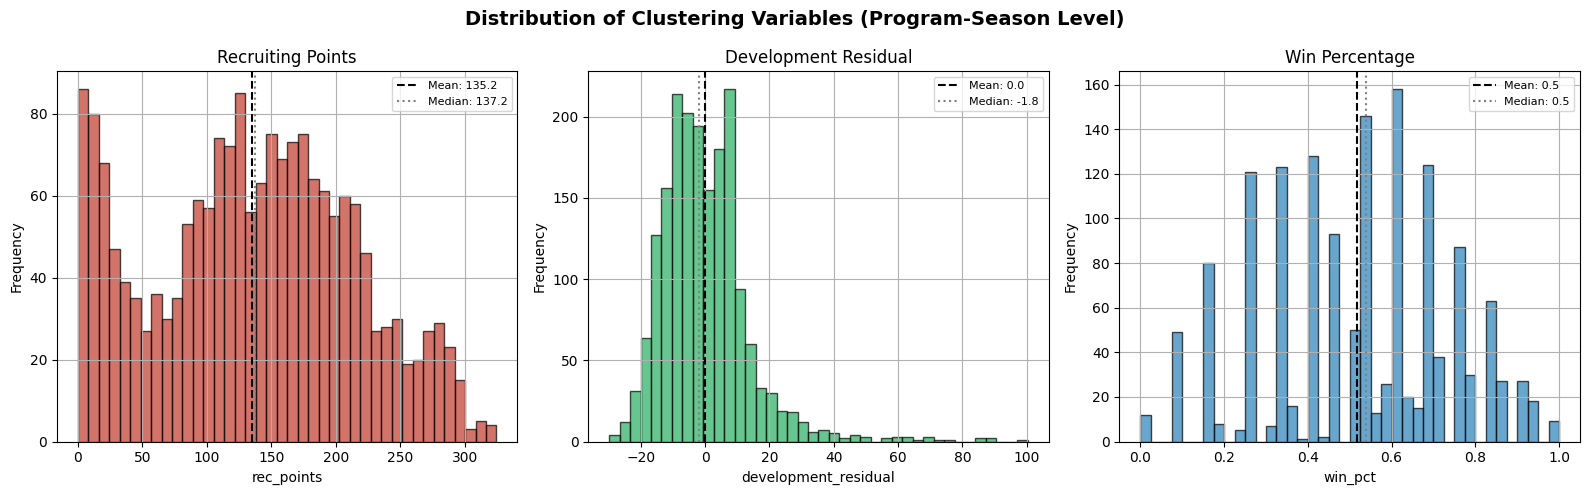

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution of Clustering Variables (Program-Season Level)",
             fontsize=14, fontweight="bold")

variables = ["rec_points", "development_residual", "win_pct"]
titles = ["Recruiting Points", "Development Residual", "Win Percentage"]
colors = ["#c0392b", "#27ae60", "#2980b9"]

for ax, var, title, color in zip(axes, variables, titles, colors):
    complete[var].dropna().hist(bins=40, ax=ax, color=color, 
                                edgecolor="black", alpha=0.7)
    ax.axvline(complete[var].mean(), color="black", linestyle="--", 
               linewidth=1.5, label=f"Mean: {complete[var].mean():.1f}")
    ax.axvline(complete[var].median(), color="gray", linestyle=":",
               linewidth=1.5, label=f"Median: {complete[var].median():.1f}")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

All 3 distributions are acceptable for the clustering that I'm going to do in the next phase.

# Clustering